# Abstraction

Entity matching (EM) tries to find same real-world entities from different data sources. In this notebook, we will try to build a POC for EM of HealthCare data.

This is small dataset, it contains many sheets. We try to process data into 2 datasets then we can compare data between 2 datasets together.
after that we try to process data and apply classification in our data. The steps would be:

**Step 1**: concatenate data and build 2 dataset **A** and **B**

**Step 2**: Apply Magellan into preprocess data

**Step 3**: Building a classification model

**Step 4**: Evaluate model

# Import library

In [4]:
# !pip install  torchtext==0.10.0  torch==1.9

In [5]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from itertools import permutations
import os 
import typing as tp
import uuid
import sys
sys.path.append('../')
sys.path.append('../src/lib/')
import src.utils.auto_config as config 
from fastai.tabular.all import *
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

try:
  import msoffcrypto
  import py_entitymatching as em
except:
  !pip install msoffcrypto-tool
finally:
  import msoffcrypto

try:
    import py_entitymatching as em
except:
    !pip install setuptools wheel
    !pip install Cython
    !pip install git+https://github.com/anhaidgroup/py_stringsimjoin.git@master
    !pip install git+https://github.com/anhaidgroup/py_entitymatching.git@master
    !pip install fasttext-wheel
finally:
  import py_entitymatching as em


import deepmatcher as dm

pd.options.display.max_columns = None

In [6]:
data_dir = '/Users/lidia/GRIT/data/'

# Data Loading

In [7]:
decrypted_workbook = io.BytesIO()
with open(data_dir + "hcp-manz-sn.xlsx", 'rb') as file:
    office_file = msoffcrypto.OfficeFile(file)
    office_file.load_key(password=config.DATA_PASSWORD)
    office_file.decrypt(decrypted_workbook)

df_dict = {}
for sheet_name in pd.read_excel(decrypted_workbook, None).keys():
  df = pd.read_excel(decrypted_workbook, sheet_name=sheet_name)
  df_dict[sheet_name] = df

# Data Exploration and Understanding

### Building pair of datasets

'(360) Validation Check' sheet contains schema that is different with other sheets. We ignore it at the moment. The sheet '(1000) Contacts' has a lots of records we could assign it as first data set **A**, others sheets will be concatenate into dataset **B**. The sheets in dataset **B** have a specific columne "Unnamed: x", we need to normalize it before concatenating them together.

In [8]:
def build_data_pair(items_in_A: tp.List[ tp.Union[str, pd.DataFrame]], items_in_B: tp.List[ tp.Union[str, pd.DataFrame]]) -> tp.Tuple[pd.DataFrame]:
    def process_items(items:tp.Union[str, pd.DataFrame]) -> tp.List[pd.DataFrame]:
        item_dfs = []
        for item in items:
            if isinstance(item, str):
                item_df = pd.read_csv(item)
                item_dfs.append(item_df)
            elif isinstance(item, pd.DataFrame):
                item_dfs.append(item)
            else:
                raise Exception("Data type is not supported!")
            
        return item_dfs
    
    A_items = process_items(items_in_A)
    B_items = process_items(items_in_B)

    return (pd.concat(A_items), pd.concat(B_items))

In [9]:
A, B = build_data_pair(
    items_in_A=[df_dict['(1000) Contacts']], 
    items_in_B=[df_dict['(800) No SAP Number and Export '], df_dict['(340) US HCPs'], df_dict['(320) OUS HCPs'], df_dict['(20) France HCPs']]
)

A.head(2)

,Status,Contact Type,Prefix,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,State/Region,Country,National Physician ID,Unnamed: 14,State License #,License State (US),Title,Specialty,Focus Area,Taxonomy,Taxonomy Code,Payment Currency,Email Address,Primary Address,Mailing Address,Primary Organization,Primary Organization Type,Quickbase Record ID#
0,Active,HCP,NaN,Gireesh Mukund,Warawdekar,Gireesh Mukund Warawdekar,Physician,NaN,NaN,NaN,NaN,NaN,India,NaN,NaN,NaN,NaN,NaN,Vascular Surgery (VS),NaN,NaN,NaN,USD,Gireesh.w@gmail.com,NaN,NaN,NaN,NaN,7676.0
1,Active,HCP,NaN,John,McGrath,John McGrath,Physician,Self,90358189,John R. McGrath,New York,NaN,United States,1134357429,NaN,NaN,NaN,NaN,Diagnostic Radiology (R),NaN,NaN,NaN,USD,JMcGrath@KaleidaHealth.org,NaN,NaN,NaN,NaN,6617.0


In [10]:
B.head(2)

,Status,Contact Type,Prefix,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,State/Region,Country,National Physician ID,Unnamed: 14,State License #,License State (US),Title,Specialty,Focus Area,Taxonomy,Taxonomy Code,Payment Currency,Email Address,Primary Address,Mailing Address,Primary Organization,Primary Organization Type,Quickbase Record ID#,Reportable HCP,Unnamed: 15,National Physician ID/RPPS ID
0,Active,HCP,NaN,Aaron,Braun,Aaron Braun,Physician,Self,NaN,NaN,Nebraska,NaN,United States,1821251083,NaN,NaN,NaN,NaN,Interventional Radiology (IR),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2309.0,NaN,NaN,NaN
1,Active,HCP,NaN,Aaron,Shiloh,Aaron Shiloh,Physician,NaN,NaN,NaN,Pennsylvania,NaN,United States,1003886896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,NaN,NaN,1061.0,NaN,NaN,NaN


In [11]:
def activate_debugging(A, B):
    A = A[A['Full Name'].isin(["Chirag Gandhi", "Chirag Gandi", "Aaron Bress", "John McGrath"])]
    B = B[B['Full Name'].isin(["Chirag Gandhi", "Chirag Gandi", "Aaron Bress", "Abdullah Shaikh"])]

    return A, B 
# A, B = activate_debugging(A, B)

# Preprocessing and Feature Engineering

<center><img src="images/preprocessing_flow.png" height = "600"/></center>

Data will be filtered by blockers in Magenlla and return 2 datasets with smaller sizes. By using blockers, we try to ignore those records that obviously non-matching:
- The first step runs filter for **A** and **B** datasets and return a candidate **K**
- second step, we use candidate **K** to continue doing blocking 
- third setp and so on, we do the same secode step (recursively) but on different column condition
- the final output, we try to generate **A'** and **B'** that have the same column names with A and B but the size is smallers. 

In [12]:
def detect_high_missing_features(df: pd.DataFrame, missing_percentage_threshold: float = 30) -> tp.List[str]:
    """Identify features in dataframe that have a lots of missing values. 
    We use a percentage threshold to capture feature that has more than that and 
    list all of them. 

    Args:
        df (pd.DataFrame): input data as DataFrame
        missing_percentage_threshold (float, optional): threshold to identify a significant missing value feature. Defaults to 30.

    Returns:
        List: a list of significant missing value features
    """
    missing_percentage = df.isna().sum()/df.shape[0] * 100
    removed_missed_features = missing_percentage[missing_percentage > missing_percentage_threshold].index
    return removed_missed_features

### Normalize feature

In [13]:
A = A.rename(columns={'Unnamed: 14': "Unnamed"})
B = B.rename(columns={'Unnamed: 15': "Unnamed"})

In [14]:
def normalize_NPI(df: pd.DataFrame):
    df['National Physician ID'] = df['National Physician ID'].fillna('UNKNOWN').astype(str)
    return df 

In [15]:
A = normalize_NPI(A)
B = normalize_NPI(B)

In [16]:
A.head()

,Status,Contact Type,Prefix,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,State/Region,Country,National Physician ID,Unnamed,State License #,License State (US),Title,Specialty,Focus Area,Taxonomy,Taxonomy Code,Payment Currency,Email Address,Primary Address,Mailing Address,Primary Organization,Primary Organization Type,Quickbase Record ID#
0,Active,HCP,NaN,Gireesh Mukund,Warawdekar,Gireesh Mukund Warawdekar,Physician,NaN,NaN,NaN,NaN,NaN,India,UNKNOWN,NaN,NaN,NaN,NaN,Vascular Surgery (VS),NaN,NaN,NaN,USD,Gireesh.w@gmail.com,NaN,NaN,NaN,NaN,7676.0
1,Active,HCP,NaN,John,McGrath,John McGrath,Physician,Self,90358189,John R. McGrath,New York,NaN,United States,1134357429,NaN,NaN,NaN,NaN,Diagnostic Radiology (R),NaN,NaN,NaN,USD,JMcGrath@KaleidaHealth.org,NaN,NaN,NaN,NaN,6617.0
2,Active,HCP,NaN,Andre,Fernandes Dallanora,Andre Fernandes Dallanora,Physician,NaN,NaN,NaN,Santa Catarina,NaN,Brazil,UNKNOWN,NaN,29195,NaN,NaN,Interventional Cardiology (IC),NaN,NaN,NaN,BRL,andredallanora@hotmail.com,NaN,NaN,NaN,NaN,7683.0
3,Active,HCP,NaN,Helmuts,Kidikas,Helmuts Kidikas,Physician,Self,90180723,Helmuts Kidikas,NaN,NaN,Latvia,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EUR,helmutskidikas@gmail.com,NaN,NaN,NaN,NaN,742.0
4,Active,HCP,NaN,Christoph,Griessenauer,Christoph Griessenauer,Physician,Self,90183682,Christoph Griessenauer,NaN,NaN,Austria,UNKNOWN,NaN,NaN,NaN,NaN,Neurosurgery (NS),NaN,NaN,NaN,EUR,christoph.griessenauer@gmail.com,NaN,NaN,NaN,NaN,6995.0


### Missing data 

In [17]:
removed_features_for_A = detect_high_missing_features(A, missing_percentage_threshold=59.2)
removed_features_for_B = detect_high_missing_features(B, missing_percentage_threshold=59.2)
removed_features = set(removed_features_for_A) & set(removed_features_for_B)
A = A[[col for col in A.columns if col not in removed_features]]
B = B[[col for col in B.columns if col not in removed_features]]

In [18]:
A.head(4)

,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Specialty,Payment Currency,Email Address,Quickbase Record ID#
0,Active,HCP,Gireesh Mukund,Warawdekar,Gireesh Mukund Warawdekar,Physician,NaN,NaN,NaN,NaN,India,UNKNOWN,Vascular Surgery (VS),USD,Gireesh.w@gmail.com,7676.0
1,Active,HCP,John,McGrath,John McGrath,Physician,Self,90358189,John R. McGrath,New York,United States,1134357429,Diagnostic Radiology (R),USD,JMcGrath@KaleidaHealth.org,6617.0
2,Active,HCP,Andre,Fernandes Dallanora,Andre Fernandes Dallanora,Physician,NaN,NaN,NaN,Santa Catarina,Brazil,UNKNOWN,Interventional Cardiology (IC),BRL,andredallanora@hotmail.com,7683.0
3,Active,HCP,Helmuts,Kidikas,Helmuts Kidikas,Physician,Self,90180723,Helmuts Kidikas,NaN,Latvia,UNKNOWN,NaN,EUR,helmutskidikas@gmail.com,742.0


In [19]:
B.head(4)

,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Unnamed: 14,Specialty,Payment Currency,Email Address,Quickbase Record ID#,Reportable HCP,National Physician ID/RPPS ID
0,Active,HCP,Aaron,Braun,Aaron Braun,Physician,Self,NaN,NaN,Nebraska,United States,1821251083,NaN,Interventional Radiology (IR),NaN,NaN,2309.0,NaN,NaN
1,Active,HCP,Aaron,Shiloh,Aaron Shiloh,Physician,NaN,NaN,NaN,Pennsylvania,United States,1003886896,NaN,NaN,USD,NaN,1061.0,NaN,NaN
2,Active,HCP,Abdullah,Shaikh,Abdullah Shaikh,Physician,NaN,NaN,NaN,NaN,United States,UNKNOWN,NaN,NaN,USD,abdullah.shaikh@ahn.org,2595.0,NaN,NaN
3,Active,HCP,Abhishek,Agrawal,Abhishek Agrawal,Physician,NaN,NaN,NaN,NaN,United States,1407155328,NaN,NaN,USD,Neuron.abhishek@gmail.com,2157.0,NaN,NaN


In [20]:
common_columns = [col for col in A.columns if col in B.columns]
A = A[common_columns]
B = B[common_columns]

In [21]:
from datetime import datetime
def fill_missing_data(df, column):
    default = None
    type = dtype_dict[column]

    if type == 'datetime64[ns]':
        df[column] = pd.to_datetime(df[column])
        return df 

    if (type == str):
        default = "UNKNOWN" 
    elif type == np.int32:
        default = -1
    elif type == np.float64:
        default = -1
    elif type == object:
        default = "UNKNOWN"
    else: 
        default = "UNKNOWN"

    df[column] = df[column].fillna(default).astype(type)

    return df 

dtype_dict = {
    'Status': str,
    'Contact Type': str,
    'First Name': str,
    'Last Name': str,
    'Full Name': str,
    'HCP Category': str,
    'Payments Made To:': str,
    'SAP Number': str,
    'SAP Entity Name': str,
    'State/Region/Province': str,
    'Country': str,
    'National Physician ID': str,
    'Unnamed': np.float64,
    'Specialty': str,
    'Payment Currency':str,
    'Email Address': str,
    'Quickbase Record ID#': np.float64,
    'Reportable HCP': 'str',
    'National Physician ID/RPPS ID': str,
    'Primary Organization': str,
    'Primary Organization Type': str
}

missing_columns_for_A = detect_high_missing_features(A, missing_percentage_threshold=0)
missing_columns_for_B = detect_high_missing_features(B, missing_percentage_threshold=0)

for col in missing_columns_for_A:
    A = fill_missing_data(A, col)

for col in missing_columns_for_B:
    B = fill_missing_data(B, col)

### Process data 

In [22]:
A.head(4)

,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Specialty,Payment Currency,Email Address,Quickbase Record ID#
0,Active,HCP,Gireesh Mukund,Warawdekar,Gireesh Mukund Warawdekar,Physician,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,India,UNKNOWN,Vascular Surgery (VS),USD,Gireesh.w@gmail.com,7676.0
1,Active,HCP,John,McGrath,John McGrath,Physician,Self,90358189,John R. McGrath,New York,United States,1134357429,Diagnostic Radiology (R),USD,JMcGrath@KaleidaHealth.org,6617.0
2,Active,HCP,Andre,Fernandes Dallanora,Andre Fernandes Dallanora,Physician,UNKNOWN,UNKNOWN,UNKNOWN,Santa Catarina,Brazil,UNKNOWN,Interventional Cardiology (IC),BRL,andredallanora@hotmail.com,7683.0
3,Active,HCP,Helmuts,Kidikas,Helmuts Kidikas,Physician,Self,90180723,Helmuts Kidikas,UNKNOWN,Latvia,UNKNOWN,UNKNOWN,EUR,helmutskidikas@gmail.com,742.0


In [23]:
B.head(3)

,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Specialty,Payment Currency,Email Address,Quickbase Record ID#
0,Active,HCP,Aaron,Braun,Aaron Braun,Physician,Self,UNKNOWN,UNKNOWN,Nebraska,United States,1821251083,Interventional Radiology (IR),UNKNOWN,UNKNOWN,2309.0
1,Active,HCP,Aaron,Shiloh,Aaron Shiloh,Physician,UNKNOWN,UNKNOWN,UNKNOWN,Pennsylvania,United States,1003886896,UNKNOWN,USD,UNKNOWN,1061.0
2,Active,HCP,Abdullah,Shaikh,Abdullah Shaikh,Physician,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,United States,UNKNOWN,UNKNOWN,USD,abdullah.shaikh@ahn.org,2595.0


### Process for SAP Number

In [24]:
def process_biSAP_number(df):
    df_1 = df.copy()
    df['SAP Number'] = df['SAP Number'].map(lambda x: x.split("\n")[0])
    df_1['SAP Number'] = df_1['SAP Number'].map(lambda x: x.split("\n")[1])

    df['SAP Entity Name'] = df['SAP Entity Name'].map(lambda x: x.split("\n")[0])
    df_1['SAP Entity Name'] = df_1['SAP Entity Name'].map(lambda x: x.split("\n")[1])

    return pd.concat([df, df_1]) 

special_SAP_df = A[A['SAP Number'].astype(str).str.contains('\n')].groupby("SAP Number").apply(process_biSAP_number).reset_index(drop = True)
A = A[~A['SAP Number'].astype(str).str.contains('\n')]
A = pd.concat([A, special_SAP_df])

special_SAP_df = B[B['SAP Number'].astype(str).str.contains('\n')].groupby("SAP Number").apply(process_biSAP_number).reset_index(drop = True)
B = B[~B['SAP Number'].astype(str).str.contains('\n')]
B = pd.concat([B, special_SAP_df])

A["SAP Number"] = A["SAP Number"].astype(str) 
B["SAP Number"] = B["SAP Number"].astype(str) 

/var/folders/qp/xc1dw7ln2hs3m70dr5rx9y1m0000gn/T/ipykernel_1094/2390934108.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  special_SAP_df = A[A['SAP Number'].astype(str).str.contains('\n')].groupby("SAP Number").apply(process_biSAP_number).reset_index(drop = True)
/var/folders/qp/xc1dw7ln2hs3m70dr5rx9y1m0000gn/T/ipykernel_1094/2390934108.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  special_SAP_

In [25]:
A.head(4)

,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Specialty,Payment Currency,Email Address,Quickbase Record ID#
0,Active,HCP,Gireesh Mukund,Warawdekar,Gireesh Mukund Warawdekar,Physician,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,India,UNKNOWN,Vascular Surgery (VS),USD,Gireesh.w@gmail.com,7676.0
1,Active,HCP,John,McGrath,John McGrath,Physician,Self,90358189,John R. McGrath,New York,United States,1134357429,Diagnostic Radiology (R),USD,JMcGrath@KaleidaHealth.org,6617.0
2,Active,HCP,Andre,Fernandes Dallanora,Andre Fernandes Dallanora,Physician,UNKNOWN,UNKNOWN,UNKNOWN,Santa Catarina,Brazil,UNKNOWN,Interventional Cardiology (IC),BRL,andredallanora@hotmail.com,7683.0
3,Active,HCP,Helmuts,Kidikas,Helmuts Kidikas,Physician,Self,90180723,Helmuts Kidikas,UNKNOWN,Latvia,UNKNOWN,UNKNOWN,EUR,helmutskidikas@gmail.com,742.0


In [26]:
B.head(3)

,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Specialty,Payment Currency,Email Address,Quickbase Record ID#
0,Active,HCP,Aaron,Braun,Aaron Braun,Physician,Self,UNKNOWN,UNKNOWN,Nebraska,United States,1821251083,Interventional Radiology (IR),UNKNOWN,UNKNOWN,2309.0
1,Active,HCP,Aaron,Shiloh,Aaron Shiloh,Physician,UNKNOWN,UNKNOWN,UNKNOWN,Pennsylvania,United States,1003886896,UNKNOWN,USD,UNKNOWN,1061.0
2,Active,HCP,Abdullah,Shaikh,Abdullah Shaikh,Physician,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,United States,UNKNOWN,UNKNOWN,USD,abdullah.shaikh@ahn.org,2595.0


In [27]:
def process_data(A, B, blocking_config: tp.Dict):
    # retrieve metadata for Magenlla
    A = A.reset_index(drop=True).reset_index().rename(columns = {"index": "id"}).drop_duplicates()
    A['id'] = 'ltable_' + A['id'].astype(str)
    B = B.reset_index(drop=True).reset_index().rename(columns = {"index": "id"}).drop_duplicates()
    B['id'] = 'rtable_' + B['id'].astype(str)

    em.set_key(A, 'id')
    em.set_key(B, 'id')

    # level 0 blocking
    creteria = blocking_config.pop('level_0')
    if creteria is not None:
        cols = list(set(B.columns) & set(A.columns))
        ob = em.OverlapBlocker()
        K = ob.block_tables(A, B, creteria, creteria, l_output_attrs=cols, r_output_attrs=cols, overlap_size=1)

        # level 1,2,... blocking
        levels = [f"level_{i}" for i in range(1, len(blocking_config))]
        for level in levels:
            creteria = blocking_config[level]
            K = ob.block_candset(K, creteria, creteria, overlap_size=1)


        ltable_columns = [col for col in K.columns if col.startswith("ltable")]
        rtable_columns = [col for col in K.columns if col.startswith("rtable")]

        new_A = K[ltable_columns]
        new_B = K[rtable_columns]
        columns = [col.replace("ltable_", "") for col in ltable_columns]
        new_A.columns = columns
        new_B.columns = columns
        new_A  = new_A.drop_duplicates()
        new_B  = new_B.drop_duplicates()
    else:
        new_A = A.copy()
        new_B = B.copy()
    return new_A, new_B

In [28]:
pd.options.mode.copy_on_write = True

blocking_config = {
    "level_0": "National Physician ID",        # remove obvious non-matching data
    "level_1": "Full Name",              # remove obvious non-matching data
}

new_A, new_B = process_data(A, B, blocking_config)

new_A.shape, new_B.shape

((602, 17), (930, 17))

In [29]:
new_A.head(4)

,id,Specialty,First Name,Email Address,National Physician ID,Full Name,Payment Currency,SAP Entity Name,Last Name,HCP Category,Payments Made To:,SAP Number,Status,State/Region/Province,Quickbase Record ID#,Country,Contact Type
0,ltable_0,Vascular Surgery (VS),Gireesh Mukund,Gireesh.w@gmail.com,UNKNOWN,Gireesh Mukund Warawdekar,USD,UNKNOWN,Warawdekar,Physician,UNKNOWN,UNKNOWN,Active,UNKNOWN,7676.0,India,HCP
1,ltable_2,Interventional Cardiology (IC),Andre,andredallanora@hotmail.com,UNKNOWN,Andre Fernandes Dallanora,BRL,UNKNOWN,Fernandes Dallanora,Physician,UNKNOWN,UNKNOWN,Active,Santa Catarina,7683.0,Brazil,HCP
2,ltable_3,UNKNOWN,Helmuts,helmutskidikas@gmail.com,UNKNOWN,Helmuts Kidikas,EUR,Helmuts Kidikas,Kidikas,Physician,Self,90180723,Active,UNKNOWN,742.0,Latvia,HCP
3,ltable_4,Neurosurgery (NS),Christoph,christoph.griessenauer@gmail.com,UNKNOWN,Christoph Griessenauer,EUR,Christoph Griessenauer,Griessenauer,Physician,Self,90183682,Active,UNKNOWN,6995.0,Austria,HCP


In [30]:
new_B.head(3)

,id,Specialty,First Name,Email Address,National Physician ID,Full Name,Payment Currency,SAP Entity Name,Last Name,HCP Category,Payments Made To:,SAP Number,Status,State/Region/Province,Quickbase Record ID#,Country,Contact Type
0,rtable_2,UNKNOWN,Abdullah,abdullah.shaikh@ahn.org,UNKNOWN,Abdullah Shaikh,USD,UNKNOWN,Shaikh,Physician,UNKNOWN,UNKNOWN,Active,UNKNOWN,2595.0,United States,HCP
595,rtable_6,UNKNOWN,Ahmed,UNKNOWN,UNKNOWN,Ahmed Ruman,GBP,UNKNOWN,Ruman,Physician,UNKNOWN,UNKNOWN,Active,UNKNOWN,6957.0,United Kingdom,HCP
1190,rtable_13,UNKNOWN,Alain,alain.weill.chum@ssss.govu.qc.ca,UNKNOWN,Alain Weill,CAD,UNKNOWN,Weill,Physician,UNKNOWN,UNKNOWN,Active,Quebec,6066.0,Canada,HCP


## Labelling data

In [31]:
def process_group(df:pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    df = df.reset_index(drop=True)
    cols1 = df.columns
    cols2 = cols1.copy()
    cols1 = ['ltable_' + c for c in cols1]
    cols2 = ['rtable_' + c for c in cols2]
    cols = cols1 + cols2
    
    if n == 1:
        new_df = pd.DataFrame(columns=cols)
        return new_df

    iter = permutations(range(n), 2)
    data = []
    for pair in iter:
        row = df.loc[pair[0]].tolist() + df.loc[pair[1]].tolist()
        data.append(row)
    new_df = pd.DataFrame(data= data, columns=cols)
    new_df['label'] = 1
    return new_df

def label_duplicated_data(df: pd.DataFrame, skewed_factor: int = 5) -> pd.DataFrame:
    """Try to label data by some conditions. The conditions we implement in this function are:
       1) Full name match
       2) National Physician ID  
       3) Email Address
       
       whenever a pair satisfies one of those condition, its label will be assinged to 1. Otherwise, its label will be assigned to 0.
    Args:
        df DataFrame: dataframe with label
    """
    duplicated_dfs = []
    full_name_duplicated_df = df[df.duplicated(keep=False, subset=['Full Name'])]
    full_name_duplicated_df = full_name_duplicated_df.groupby('Full Name').apply(process_group).reset_index(drop=True)
    if not full_name_duplicated_df.empty:
        duplicated_dfs.append(full_name_duplicated_df)

    NPI_duplicated_df = df[(df['National Physician ID']!= 'UNKNOWN') & (df.duplicated(keep=False, subset=['National Physician ID'])) & (df['National Physician ID']!='OUS')]
    NPI_duplicated_df = NPI_duplicated_df.groupby('National Physician ID').apply(process_group).reset_index(drop=True)
    if not NPI_duplicated_df.empty:
        duplicated_dfs.append(NPI_duplicated_df)

    email_duplicated_df = df[(df['Email Address']!= 'UNKNOWN') & (df.duplicated(keep=False, subset=['Email Address']))]
    email_duplicated_df = email_duplicated_df.groupby('Email Address').apply(process_group).reset_index(drop=True)
    if not email_duplicated_df.empty:
        duplicated_dfs.append(email_duplicated_df)

    label_1_df = pd.concat(duplicated_dfs)
    
    label_1_df = label_1_df.rename(columns={'ltable_id': 'id'}).drop(columns=['rtable_id'])
    label_1_df['label'] = 1

    label_0_df = df[~df.id.isin(label_1_df.id.unique())]

    label_0_df = process_group(label_0_df)
    label_0_df = label_0_df.rename(columns={'ltable_id': 'id'}).drop(columns=['rtable_id'])
    label_0_df['label'] = 0
    
    # sampling with skewed factor
    n_1 = label_1_df.shape[0]
    n_0 = len(label_0_df)
    
    if n_0 < n_1 :
        n = n_0 * skewed_factor
        n = n if n < n_1 else len(label_0_df)
        label_1_df = label_1_df.sample(n, random_state=1)
    else:
        n = n_1 * skewed_factor
        n = n if n < n_0 else len(label_0_df)
        label_0_df = label_0_df.sample(n, random_state=1)

    data_df = pd.concat([label_0_df, label_1_df]).drop_duplicates()
    return data_df, label_1_df, label_0_df, full_name_duplicated_df, NPI_duplicated_df, email_duplicated_df

In [32]:
df = pd.concat([new_A, new_B])
df, label_1_df, label_0_df, full_name_duplicated_df, NPI_duplicated_df, email_duplicated_df = label_duplicated_data(df, skewed_factor=2)

/var/folders/qp/xc1dw7ln2hs3m70dr5rx9y1m0000gn/T/ipykernel_1094/2908804377.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  full_name_duplicated_df = full_name_duplicated_df.groupby('Full Name').apply(process_group).reset_index(drop=True)
/var/folders/qp/xc1dw7ln2hs3m70dr5rx9y1m0000gn/T/ipykernel_1094/2908804377.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  NPI_duplicated_df = NPI_duplicated_df.g

In [33]:
selected_columns = ['id','ltable_Full Name', 'rtable_Full Name', 'ltable_National Physician ID', 'rtable_National Physician ID', 'ltable_Email Address', 'rtable_Email Address', 'label']
df[df['ltable_Full Name'].isin(["Chirag Gandhi", "Chirag Gandi", "Aaron Bress"])][selected_columns]

,id,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,label
0,ltable_361,Chirag Gandhi,Chirag Gandi,1316068927,1316068927,Chirag.gandhi@wmchealth.org,UNKNOWN,1
1,rtable_147,Chirag Gandi,Chirag Gandhi,1316068927,1316068927,UNKNOWN,Chirag.gandhi@wmchealth.org,1


In [34]:
df[selected_columns].head(10).reset_index(drop = True)

,id,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,label
0,rtable_157,Christopher Davis,Gianpiero Locatelli,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
1,ltable_426,Andrew Galbiati,Branden Garcia,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
2,rtable_436,Krista Davis,Bruno Parente,UNKNOWN,UNKNOWN,kitee1418@yahoo.com,brunoparente@doctor.com,0
3,rtable_16,Alberto Lopez,Heiko Wendorff,UNKNOWN,UNKNOWN,a.lopez33@med.miami.edu,Heiko.Wendorff@mri.tum.de,0
4,ltable_697,Romain Bourcier,Kristen Alexa Lee,UNKNOWN,UNKNOWN,romain.bourcier2@gmail.com,kristen.alexa.lee@singhealth.com.sg,0
5,rtable_775,U.O.C. Neuroradiologia Azienda Ospedaliera Universitaria Gaetano Martino,Daniele Savio,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
6,rtable_556,Nathan Zimmerman,David Kim,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
7,rtable_297,Hiroyuki Matsumoto,Kenneth Murphy,UNKNOWN,UNKNOWN,UNKNOWN,melody_musso@urmc.rocheste.edu,0
8,rtable_396,Julie Palmer,Shian Patel,UNKNOWN,UNKNOWN,UNKNOWN,shian.patel@uhs.nhs.uk,0
9,rtable_730,Stephanie Woodward,Tuan-Jay Nguyen,UNKNOWN,UNKNOWN,Swoodward@bwmc.umms.org,UNKNOWN,0


In [35]:
label_0_df[selected_columns].head(3).reset_index(drop = True)

,id,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,label
0,rtable_157,Christopher Davis,Gianpiero Locatelli,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
1,ltable_426,Andrew Galbiati,Branden Garcia,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0
2,rtable_436,Krista Davis,Bruno Parente,UNKNOWN,UNKNOWN,kitee1418@yahoo.com,brunoparente@doctor.com,0


In [36]:
label_1_df[selected_columns].head(10).reset_index(drop = True)

,id,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,label
0,ltable_544,ALEKSANDER ARASZKIEWICZ,ALEKSANDER ARASZKIEWICZ,UNKNOWN,UNKNOWN,aaraszkiewicz@interia.pl,aaraszkiewicz@interia.pl,1
1,rtable_1325,ALEKSANDER ARASZKIEWICZ,ALEKSANDER ARASZKIEWICZ,UNKNOWN,UNKNOWN,aaraszkiewicz@interia.pl,aaraszkiewicz@interia.pl,1
2,ltable_715,Abdul Alvi,Abdul Alvi,UNKNOWN,UNKNOWN,Abdul.alvi@bhrhospitals.nhs.uk,Abdul.alvi@bhrhospitals.nhs.uk,1
3,rtable_1283,Abdul Alvi,Abdul Alvi,UNKNOWN,UNKNOWN,Abdul.alvi@bhrhospitals.nhs.uk,Abdul.alvi@bhrhospitals.nhs.uk,1
4,ltable_657,Abdul Rahman Jan Alvi,Abdul Rahman Jan Alvi,UNKNOWN,UNKNOWN,arjalvi@gmail.com,arjalvi@gmail.com,1
5,rtable_1284,Abdul Rahman Jan Alvi,Abdul Rahman Jan Alvi,UNKNOWN,UNKNOWN,arjalvi@gmail.com,arjalvi@gmail.com,1
6,ltable_482,Adam Kobayashi,Adam Kobayashi,UNKNOWN,UNKNOWN,akobayashi@ipin.edu.pl,akobayashi@ipin.edu.pl,1
7,rtable_1357,Adam Kobayashi,Adam Kobayashi,UNKNOWN,UNKNOWN,akobayashi@ipin.edu.pl,akobayashi@ipin.edu.pl,1
8,ltable_685,Ahmad Rafizi Hariz Bin Ramli,Ahmad Rafizi Hariz Bin Ramli,UNKNOWN,UNKNOWN,arhariz@um.edu.my,arhariz@um.edu.my,1
9,rtable_1222,Ahmad Rafizi Hariz Bin Ramli,Ahmad Rafizi Hariz Bin Ramli,UNKNOWN,UNKNOWN,arhariz@um.edu.my,arhariz@um.edu.my,1


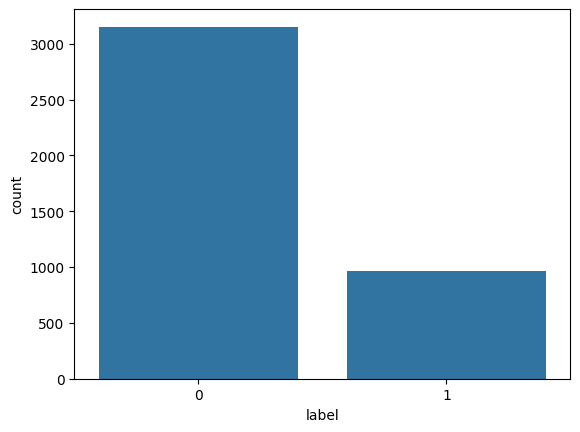

In [37]:
sns.countplot(x = 'label', data = df)
plt.show()

# Building Model

### Using deepmatcher

In [38]:
del df['id']

In [39]:
dm.data.split(df, data_dir, 'train.csv', 'valid.csv', 'test.csv',[3, 1, 1])

In [40]:
train, validation, test = dm.data.process(
    path=data_dir,
    cache='train_cache0.pth',
    train='train.csv',
    validation='valid.csv',
    test='test.csv',
    use_magellan_convention=True)

In [41]:
model = dm.MatchingModel(attr_summarizer='hybrid')
model.run_train(train, validation, epochs=3, batch_size=16, best_save_path=None, pos_neg_ratio=3)

/Users/lidia/GRIT/ragenv/lib/python3.9/site-packages/torch/nn/modules/module.py:949: UserWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not take as input a "
/Users/lidia/GRIT/ragenv/lib/python3.9/site-packages/torch/nn/modules/module.py:974: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


* Number of trainable parameters: 35333818
===>  TRAIN Epoch 1


/Users/lidia/GRIT/ragenv/lib/python3.9/site-packages/torch/nn/modules/module.py:939: UserWarning: Using non-full backward hooks on a Module that does not return a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_output. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not return a "
/Users/lidia/GRIT/ragenv/lib/python3.9/site-packages/torch/nn/functional.py:2741: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Finished Epoch 1 || Run Time:  254.4 | Load Time:    1.2 || F1:  91.37 | Prec:  86.82 | Rec:  96.43 || Ex/s:   9.68

===>  EVAL Epoch 1
Finished Epoch 1 || Run Time:   32.8 | Load Time:    0.4 || F1:  98.52 | Prec: 100.00 | Rec:  97.09 || Ex/s:  24.77

* Best F1: tensor(98.5222)
---------------------

===>  TRAIN Epoch 2
Finished Epoch 2 || Run Time:  239.1 | Load Time:    1.1 || F1:  99.55 | Prec:  99.47 | Rec:  99.64 || Ex/s:  10.29

===>  EVAL Epoch 2
Finished Epoch 2 || Run Time:   28.3 | Load Time:    0.4 || F1:  98.77 | Prec: 100.00 | Rec:  97.57 || Ex/s:  28.68

* Best F1: tensor(98.7715)
---------------------

===>  TRAIN Epoch 3
Finished Epoch 3 || Run Time:  228.1 | Load Time:    1.0 || F1:  99.91 | Prec: 100.00 | Rec:  99.82 || Ex/s:  10.79

===>  EVAL Epoch 3
Finished Epoch 3 || Run Time:   27.3 | Load Time:    0.4 || F1:  98.77 | Prec: 100.00 | Rec:  97.57 || Ex/s:  29.75

---------------------

Loading best model...


AttributeError: 'NoneType' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.

In [ ]:
model.run_eval(test)

===>  EVAL Epoch 3


Finished Epoch 3 || Run Time:    7.3 | Load Time:    0.2 || F1:  99.71 | Prec: 100.00 | Rec:  99.42 || Ex/s: 109.46



99.71014492753623

## Usecase

In [ ]:
# test_df = pd.read_csv(os.path.join(data_dir, 'test.csv'))
# test_df = test_df.reset_index(drop=True).reset_index().rename(columns = {"index": "_id"})
# test_df.to_csv(os.path.join(data_dir, 'new_data.csv'))
# test_df.head()

,_id,ltable_Contact Type,ltable_Specialty,ltable_Country,ltable_State/Region/Province,ltable_Last Name,ltable_Full Name,ltable_First Name,ltable_HCP Category,ltable_SAP Number,ltable_Email Address,ltable_National Physician ID,ltable_Status,ltable_Payments Made To:,ltable_Quickbase Record ID#,ltable_Payment Currency,ltable_SAP Entity Name,rtable_Contact Type,rtable_Specialty,rtable_Country,rtable_State/Region/Province,rtable_Last Name,rtable_Full Name,rtable_First Name,rtable_HCP Category,rtable_SAP Number,rtable_Email Address,rtable_National Physician ID,rtable_Status,rtable_Payments Made To:,rtable_Quickbase Record ID#,rtable_Payment Currency,rtable_SAP Entity Name,label
0,0,HCP,UNKNOWN,France,UNKNOWN,Cornelis,Francois Cornelis,Francois,Physician,UNKNOWN,UNKNOWN,UNKNOWN,Active,UNKNOWN,650.0,UNKNOWN,UNKNOWN,HCP,UNKNOWN,United States,California,Khan,Amir Khan,Amir,Physician,UNKNOWN,akhan@communitymedical.org,UNKNOWN,Active,UNKNOWN,1713.0,USD,UNKNOWN,0
1,1,HCP,UNKNOWN,United States,UNKNOWN,Lewis,Garfield Lewis,Garfield,Technician,UNKNOWN,garfield_lewisjr@yahoo.com,UNKNOWN,Active,UNKNOWN,3214.0,UNKNOWN,UNKNOWN,HCP,UNKNOWN,United States,New York,Sanborn,Mathew Sanborn,Mathew,Physician,UNKNOWN,UNKNOWN,UNKNOWN,Active,UNKNOWN,5679.0,UNKNOWN,UNKNOWN,0
2,2,HCP,UNKNOWN,United States,UNKNOWN,Shaikh,Abdullah Shaikh,Abdullah,Physician,UNKNOWN,abdullah.shaikh@ahn.org,UNKNOWN,Active,UNKNOWN,2595.0,USD,UNKNOWN,HCP,0,Korea,UNKNOWN,Moon,Byung hoo Moon,Byung hoo,Physician,UNKNOWN,UNKNOWN,UNKNOWN,Active,UNKNOWN,5699.0,UNKNOWN,UNKNOWN,0
3,3,HCP,UNKNOWN,Canada,UNKNOWN,Rohr,Axel Rohr,Axel,Physician,UNKNOWN,icketown@gmail.com,UNKNOWN,Active,UNKNOWN,1615.0,CAD,UNKNOWN,HCP,Interventional Cardiology (IC),Brazil,Minas Gerais,Neves Ferreira,Antonio Carlos Neves Ferreira,Antonio Carlos,Physician,UNKNOWN,acarlostune@gmail.com,UNKNOWN,Active,UNKNOWN,7605.0,BRL,UNKNOWN,0
4,4,HCP,UNKNOWN,United States,Tennessee,Adams,Stacy Adams,Stacy,Technician,UNKNOWN,UNKNOWN,UNKNOWN,Active,UNKNOWN,2608.0,USD,UNKNOWN,HCP,UNKNOWN,United Kingdom,UNKNOWN,Rane,Neil Rane,Neil,Physician,UNKNOWN,UNKNOWN,UNKNOWN,Active,UNKNOWN,1576.0,UNKNOWN,UNKNOWN,0


In [ ]:
candidate = dm.data.process_unlabeled(
    path=os.path.join(data_dir, 'new_data.csv'),
    trained_model=model,
    ignore_columns=('ltable_id', 'rtable_id', 'label'))

In [ ]:
predictions = model.run_prediction(candidate, output_attributes=list(candidate.get_raw_table().columns))
predictions = predictions.rename(columns={"match_score":"confident"})

===>  PREDICT Epoch 3


/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:949: UserWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not take as input a "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:974: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-p

Finished Epoch 3 || Run Time:    6.8 | Load Time:    0.2 || F1:   0.00 | Prec:   0.00 | Rec:   0.00 || Ex/s:   0.00



In [ ]:
selected_columns = [
 'ltable_Full Name',
 'rtable_Full Name',
 'ltable_National Physician ID',
 'rtable_National Physician ID',
 'ltable_Email Address',
 'rtable_Email Address',
 'confident', 'is_matched',
 'label']

threshold = 0.8
predictions['is_matched'] = np.where(predictions['confident'] > threshold, 1, 0)
predictions.query("(is_matched == 0) & (label == 1) ")[selected_columns].tail(20).reset_index()

,_id,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,confident,is_matched,label
0,124,Mark Howard,John Monteith,UNKNOWN,UNKNOWN,ldefilippo@penumbrainc.com,ldefilippo@penumbrainc.com,0.784847,0,1
1,629,Donny Rodriguez,Virginia Rodriguez,UNKNOWN,UNKNOWN,donqdeedee@aol.com,donqdeedee@aol.com,0.139194,0,1


In [ ]:
check_threshold = 0.96
np.sum(predictions['confident'] > check_threshold), np.sum(predictions['label'] ==1), np.sum(predictions['label'] ==1) - np.sum(predictions['confident'] > check_threshold)

(171, 173, 2)

In [ ]:
predictions[selected_columns].head(20)

,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,ltable_Email Address,rtable_Email Address,confident,is_matched,label
_id,,,,,,,,,
0,Francois Cornelis,Amir Khan,UNKNOWN,UNKNOWN,UNKNOWN,akhan@communitymedical.org,0.130470,0,0
1,Garfield Lewis,Mathew Sanborn,UNKNOWN,UNKNOWN,garfield_lewisjr@yahoo.com,UNKNOWN,0.136365,0,0
2,Abdullah Shaikh,Byung hoo Moon,UNKNOWN,UNKNOWN,abdullah.shaikh@ahn.org,UNKNOWN,0.130868,0,0
3,Axel Rohr,Antonio Carlos Neves Ferreira,UNKNOWN,UNKNOWN,icketown@gmail.com,acarlostune@gmail.com,0.142443,0,0
4,Stacy Adams,Neil Rane,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0.131589,0,0
5,Luigi Simonetti,Davide Leni,UNKNOWN,UNKNOWN,bpoppi@penumbrainc.com,bpoppi@penumbrainc.com,0.983225,1,1
6,Serafino (Maria) Santonocito,Stefano Gennai,UNKNOWN,UNKNOWN,rpanzetti@penumbrainc.com,rpanzetti@penumbrainc.com,0.985310,1,1
7,Marcy Perez,Kevin Mulholland,UNKNOWN,UNKNOWN,maricelaperez77@yahoo.com,Kevcjbren@AOL.com,0.134702,0,0
8,Amy Lassiter,Aldo Paolucci,UNKNOWN,UNKNOWN,amylassiterrn@gmail.com,UNKNOWN,0.135569,0,0


## Using traditional ML approaches

In [42]:
def build_tabular_dataloader(df,  dep_var = 'n_trips'):
    cont,cat = cont_cat_split(df, 20, dep_var=dep_var)

    np.random.seed(0)
    valid_idx = np.random.choice(df.shape[0], len(df)//10*3, replace=False)
    train_idx = range(valid_idx[-1], df.shape[0])
    

    splits = (list(train_idx),list(valid_idx))
    procs = [Categorify, FillMissing]
    to = TabularPandas(df, procs, cat, cont, y_names=dep_var, splits=splits)

    return to, cont, cat

def rf_feat_importance(m, features):
    return pd.DataFrame({'cols':features, 'imp':m.feature_importances_}).sort_values('imp', ascending=False)


In [43]:
selected_features =[ f for f in  df.columns.tolist() if f!="id"]
regression_dataloader, cont, cat = build_tabular_dataloader(df[selected_features], dep_var='label')
xs,y = regression_dataloader.train.xs, regression_dataloader.train.y
valid_xs,valid_y = regression_dataloader.valid.xs, regression_dataloader.valid.y

In [44]:
models = {
    'LogisticRegression': LogisticRegression(), 
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'XGBClassifier': XGBClassifier()
}

In [45]:
validation_results = {}
for model_name, model in models.items():
    model.fit(xs, y)
    y_pred = model.predict(valid_xs)
    score =accuracy_score(valid_y,y_pred)
    validation_results[model_name] = score

/Users/lidia/GRIT/ragenv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/lidia/GRIT/ragenv/lib/python3.9/site-packages/threadpoolctl.py:1223: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/m

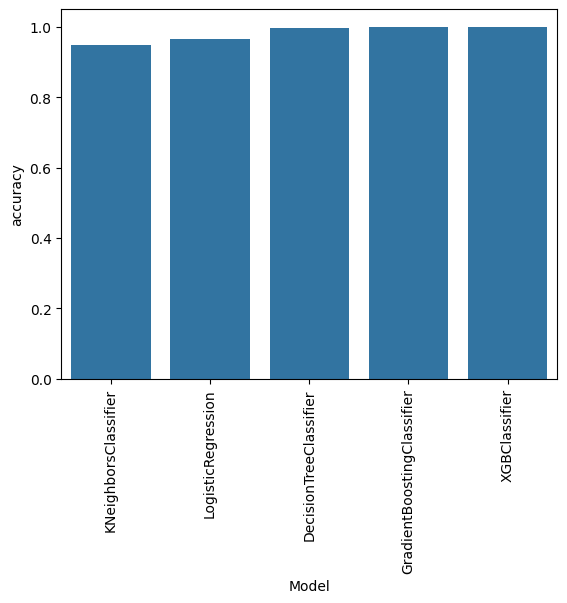

In [46]:
validation_results = {k:v for k,v in sorted(validation_results.items(), key = lambda item: item[1])}

ax = sns.barplot(x = list(validation_results.keys()), y = list(validation_results.values()))
ax.set(xlabel='Model', ylabel='accuracy')
for item in ax.get_xticklabels():
    item.set_rotation(90)

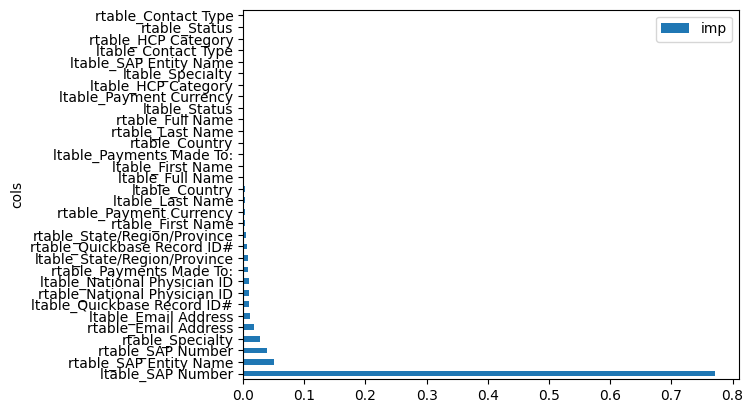

In [47]:
fi = rf_feat_importance(models['XGBClassifier'], models['XGBClassifier'].get_booster().feature_names)
fi.plot.barh(x='cols', y='imp', rot=0)
plt.show()
